# Notebook 2: TsSHAP End-to-End Evaluation on Synthetic Data

We generate a synthetic series from **known components** (trend, seasonality, noise) so we can sanity-check TsSHAP: the ground truth tells us which structural parts of the signal are large, which we compare to recovered feature importances where it makes sense (e.g. STL features).

**Experiments (run top to bottom):**

1. **Baseline pipeline — seasonality-heavy synthetic data** — Build the series, fit `TsSHAPExplainer` with a Seasonal Naive forecaster and a fixed feature set, then inspect **global** importance and how well the surrogate tracks the black-box backtested forecasts.

2. **Local explanation** — SHAP-style attributions at a **single** time index (why this forecast step?).

3. **Semi-local explanation** — Aggregate attributions over a **window** of recent time indices (here, the last 12 steps).

4. **Surrogate fidelity across forecasters** — Hold the synthetic series and features fixed; swap the black-box across **every** bundled forecaster (Naive, Seasonal Naive, moving average, exponential smoothing, XGBoost, Prophet). For each model we plot surrogate vs black-box forecasts and global importance with the **forecaster name as the figure suptitle**, then report MAPE from `surrogate_accuracy`. Same *style* of check as surrogate error tables in the paper, on this synthetic benchmark.

5. **Ground-truth vs STL importances** — Compare global STL-related TsSHAP importances to the **variance shares** of the known trend/seasonal components from the synthetic generator (qualitative alignment).

6. **Efficiency** — Time **surrogate training** and **SHAP** computation for different surrogate backends (e.g. sklearn / XGBoost / LightGBM when available) and series lengths; compare **TreeSHAP** vs **KernelSHAP** on a small sample; plot MAE/time tradeoffs.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from evaluation.synthetic_data import make_trend_seasonal
from tsshap import TsSHAPExplainer
from tsshap.features import STLFeatures, LagFeatures, SeasonalLagFeatures, TrendFeatures, RollingWindowFeatures
from tsshap.forecasters import MovingAverageForecaster, SeasonalNaiveForecaster, NaiveForecaster
from tsshap.explanations import plot_importance, plot_forecasts

## Experiment 1: Baseline pipeline (seasonality-heavy synthetic data)

Ground truth: large seasonal amplitude, modest trend, small noise — so a Seasonal Naive forecaster and seasonal/STL-related features are a natural sanity check.

Ground-truth component fractions (variance explained):
  trend       : 0.16%
  seasonal    : 98.96%
  noise       : 0.90%


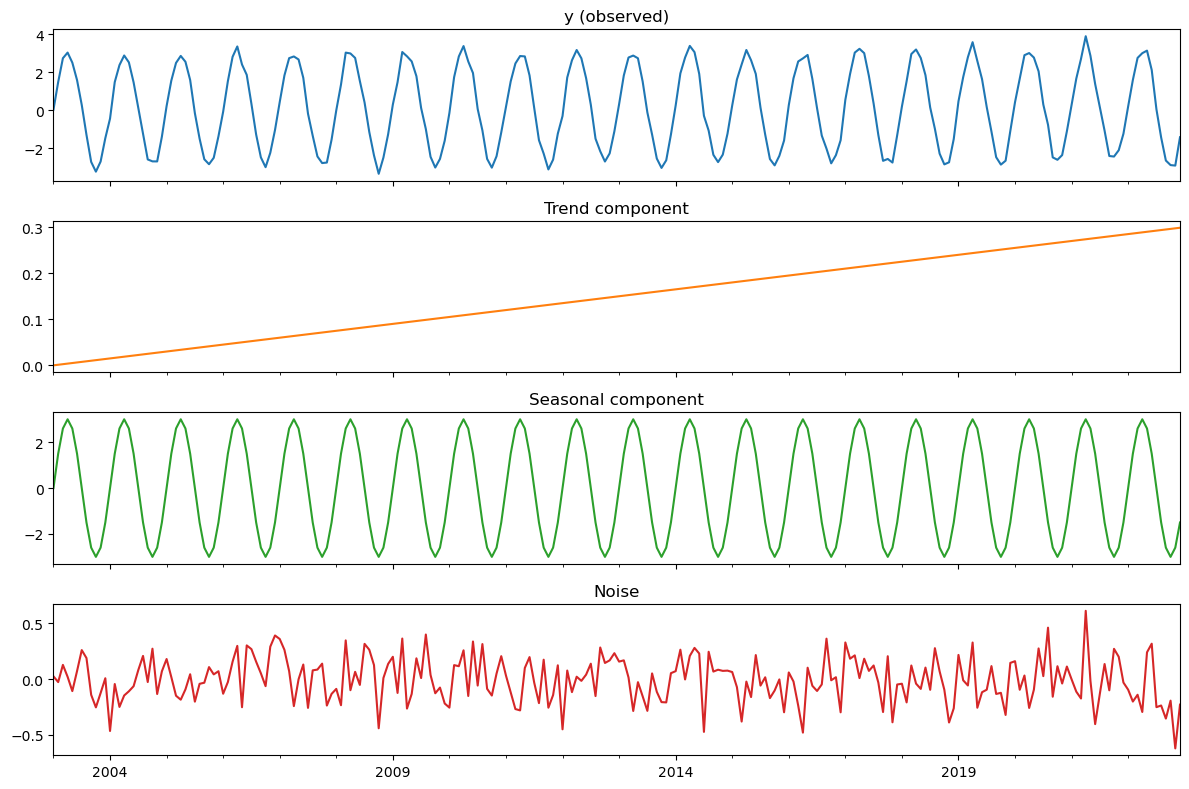

In [2]:
synth = make_trend_seasonal(
    n=240, period=12,
    trend_slope=0.3,
    seasonal_amplitude=3.0,
    noise_std=0.2,
    freq='ME',
)
y = synth.series

print('Ground-truth component fractions (variance explained):')
for k, v in synth.component_fractions().items():
    print(f'  {k:12s}: {v:.2%}')

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
y.plot(ax=axes[0], title='y (observed)')
synth.trend.plot(ax=axes[1], title='Trend component', color='C1')
synth.seasonal.plot(ax=axes[2], title='Seasonal component', color='C2')
synth.noise.plot(ax=axes[3], title='Noise', color='C3')
plt.tight_layout()
plt.show()

In [3]:
# Fit TsSHAP with a mix of feature families
feature_extractors = [
    STLFeatures(period=12, robust=True),
    LagFeatures(lags=3),
    SeasonalLagFeatures(lags=2, period=12),
    TrendFeatures(degree=2),
    RollingWindowFeatures(window=6, stats=('mean',)),
]

forecaster = SeasonalNaiveForecaster(period=12)
explainer = TsSHAPExplainer(
    forecaster=forecaster,
    feature_extractors=feature_extractors,
    horizon=12,
)
explainer.fit(y)
print(f'Surrogate R²: {explainer.surrogate.score(explainer.feature_matrix.fillna(0), explainer.backtest_result.forecasts):.4f}')

Surrogate R²: 1.0000


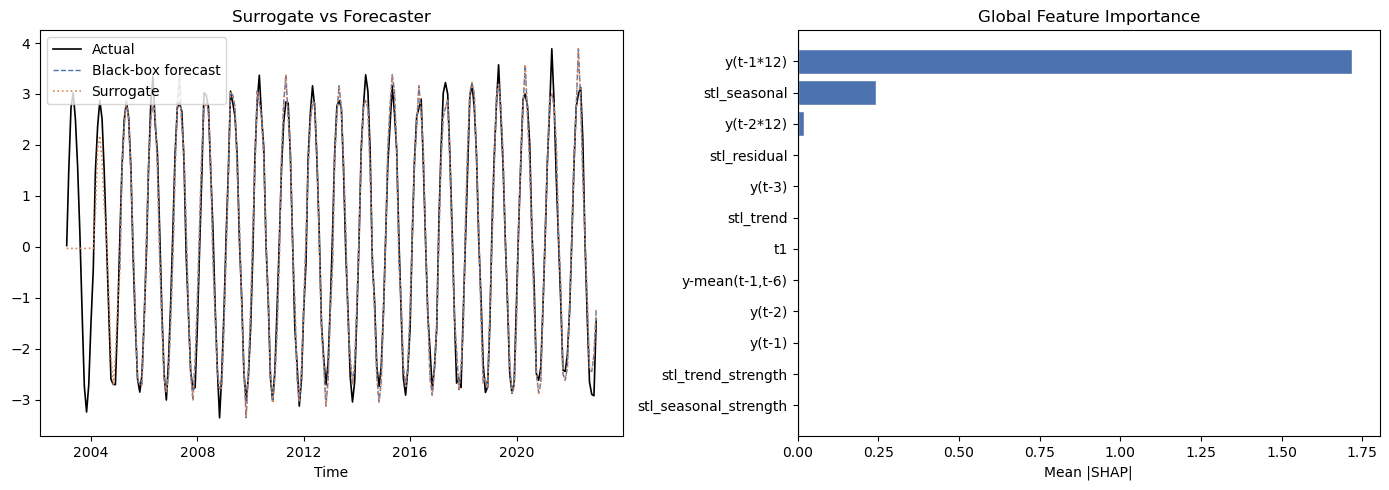


Top features:
y(t-1*12)          1.719169
stl_seasonal       0.242018
y(t-2*12)          0.018808
stl_residual       0.002108
y(t-3)             0.001619
stl_trend          0.001383
t1                 0.001330
y-mean(t-1,t-6)    0.001021
dtype: float32


In [4]:
result_global = explainer.explain(scope='global')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_forecasts(result_global, ax=axes[0], title='Surrogate vs Forecaster')
plot_importance(result_global, top_n=12, ax=axes[1], title='Global Feature Importance')
plt.tight_layout()
plt.show()

print('\nTop features:')
print(result_global.top_features(8))

## Experiment 2: Local explanation (single timestep)

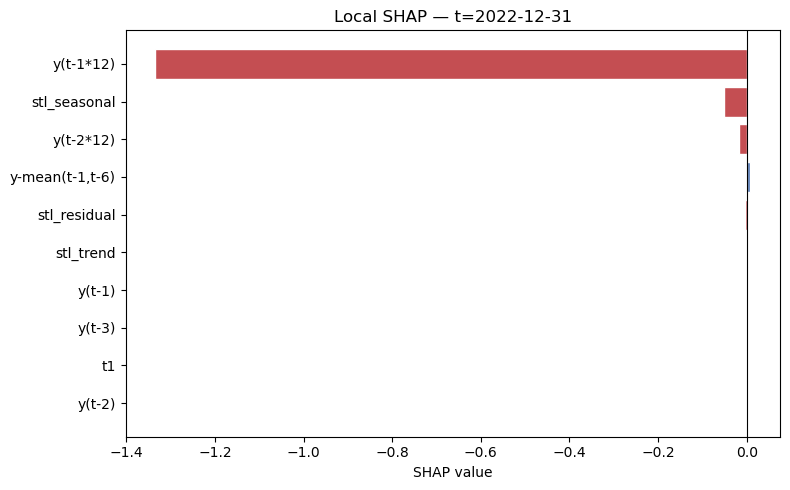

Base value: 0.148
Surrogate pred: -1.247


In [5]:
# Explain the last time step
result_local = explainer.explain(scope='local', t=-1)

fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(result_local, top_n=10, ax=ax, title=f'Local SHAP — t={y.index[-1].date()}')
plt.show()

print(f'Base value: {result_local.base_value:.3f}')
print(f'Surrogate pred: {result_local.surrogate_preds.iloc[0]:.3f}')

## Experiment 3: Semi-local explanation (last 12 steps)

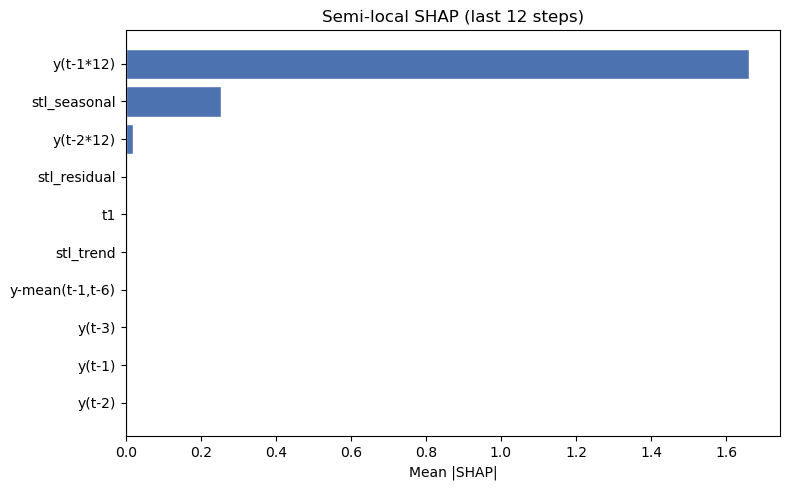

In [6]:
n = len(y)
result_semi = explainer.explain(scope='semi-local', t_start=n-12, t_end=n)

fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(result_semi, top_n=10, ax=ax, title='Semi-local SHAP (last 12 steps)')
plt.show()

## Experiment 4: Surrogate fidelity across forecasters

Same synthetic series and feature extractors as Experiment 1; only the black-box forecaster changes. We loop over every forecaster implemented in the package (naive, seasonal naive, moving average, exponential smoothing, XGBoost, Prophet); each iteration shows a **figure suptitled with the forecaster name** alongside surrogate-vs-forecaster and importance panels. We then measure how closely the surrogate matches each forecaster’s backtested predictions (e.g. MAPE via `surrogate_accuracy`). Conceptually similar to surrogate–forecaster error tables in the paper (e.g. Table 5), but on this synthetic benchmark only.

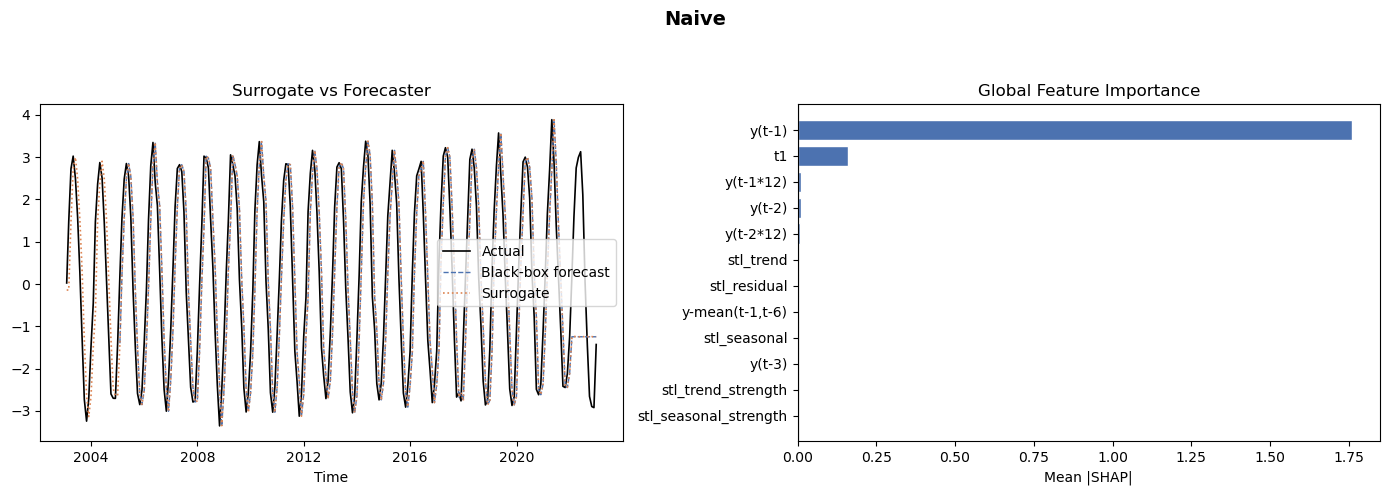

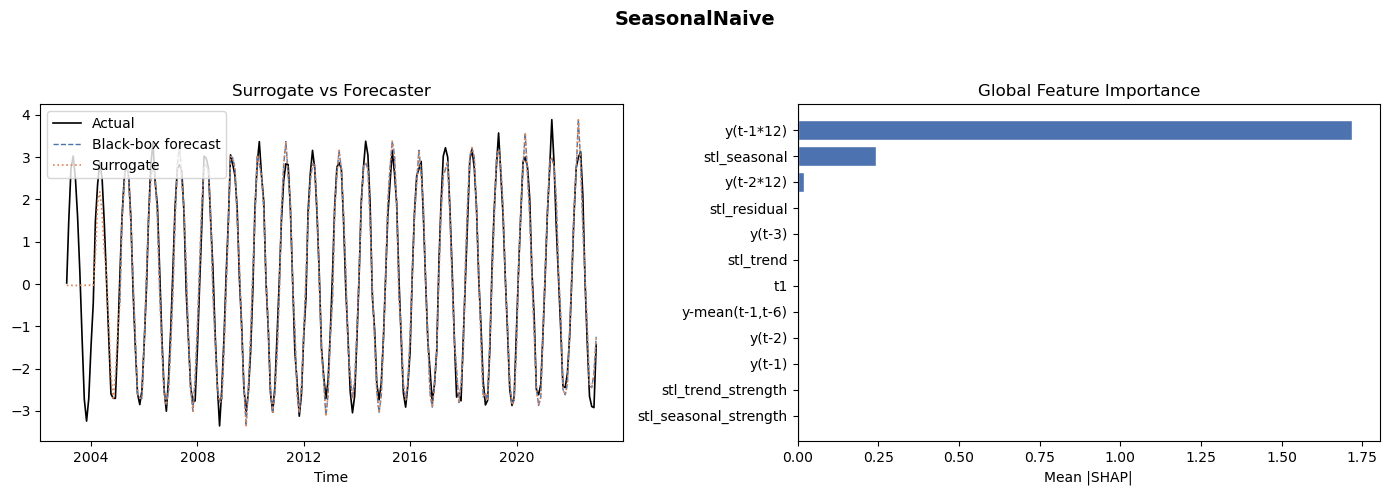

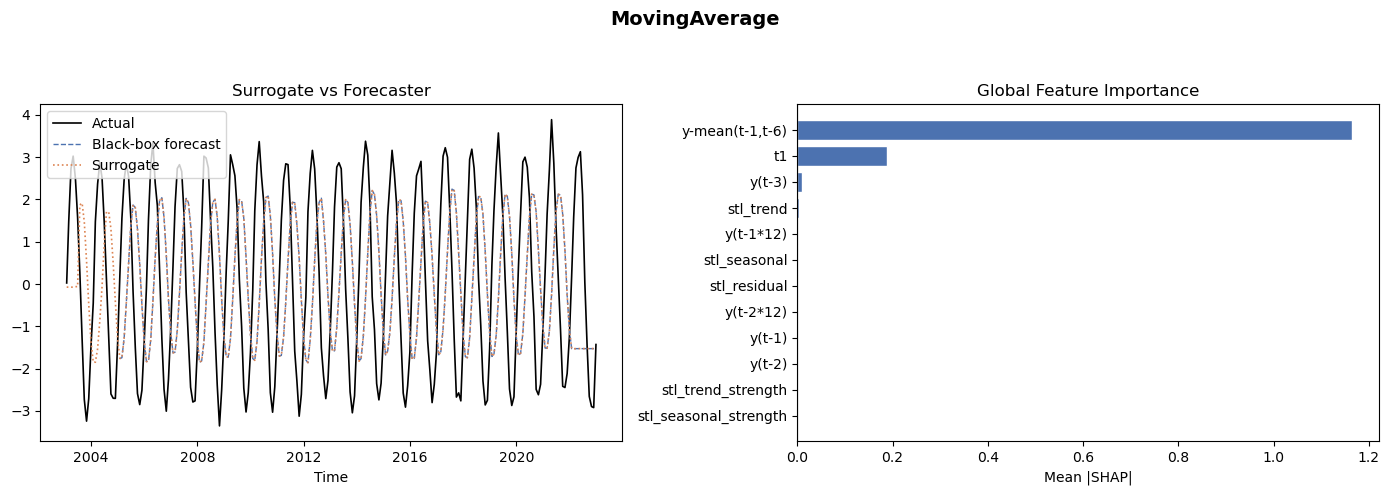

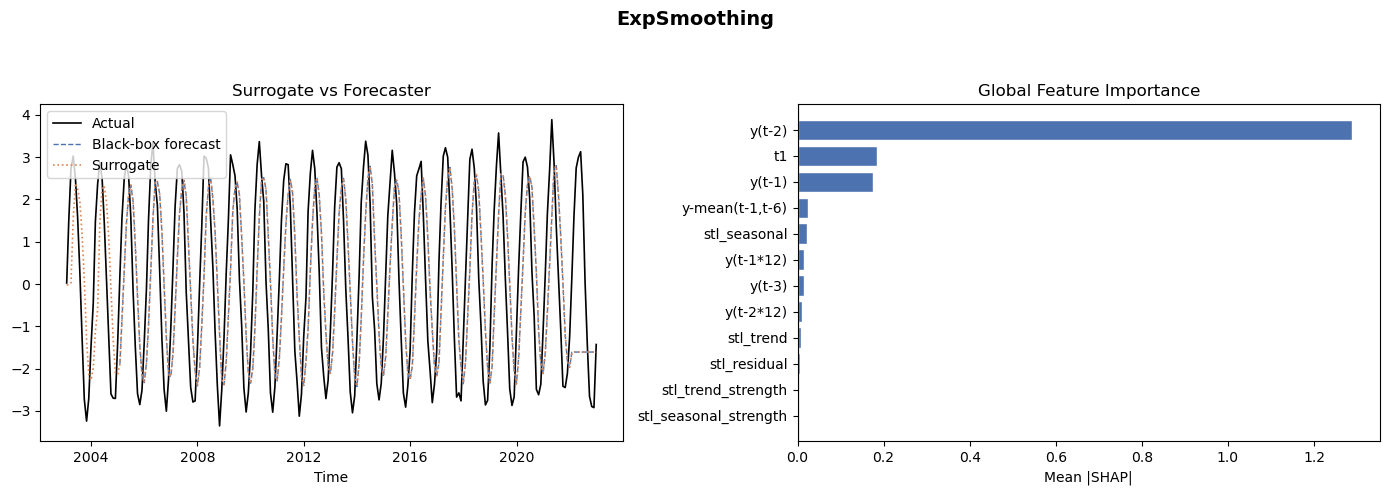

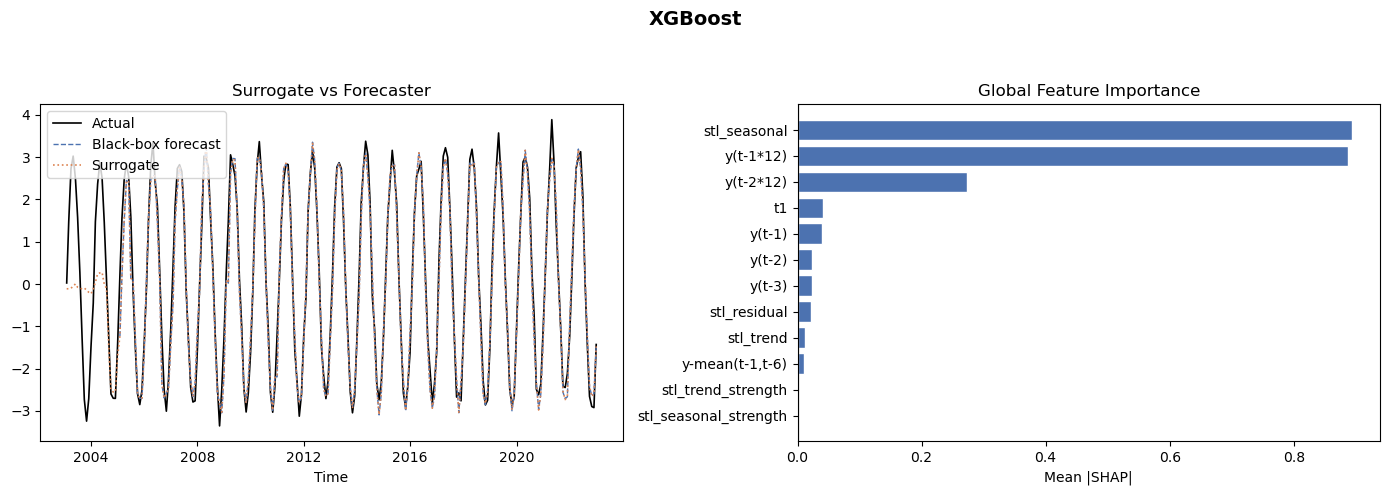

Importing plotly failed. Interactive plots will not work.
08:10:49 - cmdstanpy - INFO - Chain [1] start processing
08:10:49 - cmdstanpy - INFO - Chain [1] done processing
08:10:49 - cmdstanpy - INFO - Chain [1] start processing
08:10:55 - cmdstanpy - INFO - Chain [1] done processing
08:10:55 - cmdstanpy - INFO - Chain [1] start processing
08:10:55 - cmdstanpy - INFO - Chain [1] done processing
08:10:55 - cmdstanpy - INFO - Chain [1] start processing
08:10:55 - cmdstanpy - INFO - Chain [1] done processing
08:10:55 - cmdstanpy - INFO - Chain [1] start processing
08:10:55 - cmdstanpy - INFO - Chain [1] done processing
08:10:55 - cmdstanpy - INFO - Chain [1] start processing
08:10:55 - cmdstanpy - INFO - Chain [1] done processing
08:10:55 - cmdstanpy - INFO - Chain [1] start processing
08:10:55 - cmdstanpy - INFO - Chain [1] done processing
08:10:55 - cmdstanpy - INFO - Chain [1] start processing
08:10:56 - cmdstanpy - INFO - Chain [1] done processing
08:10:56 - cmdstanpy - INFO - Chain [1

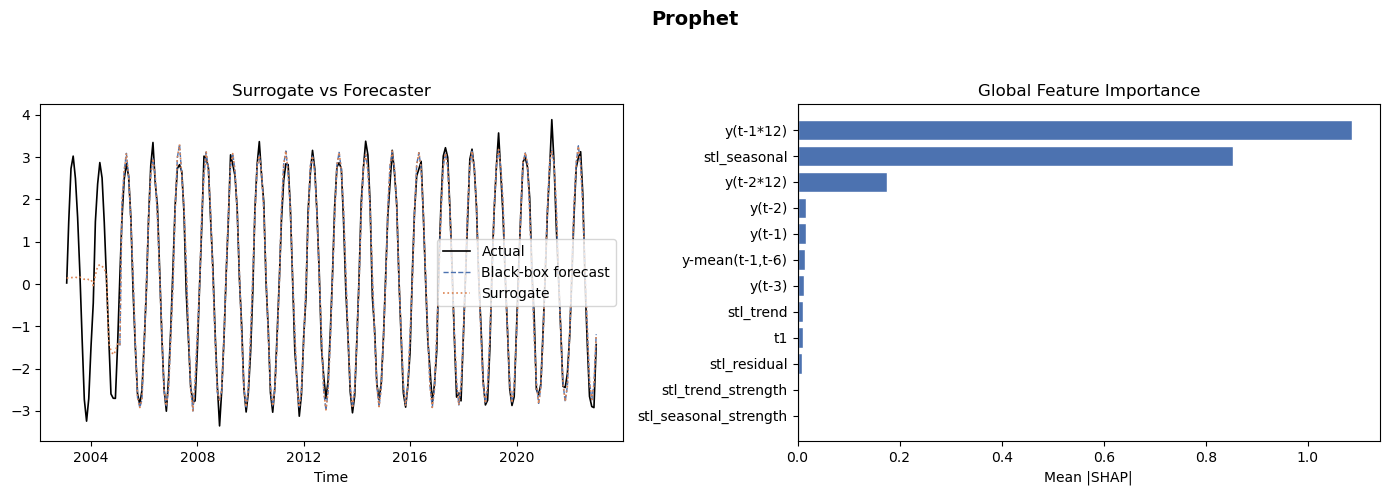

                 MAPE
forecaster           
Naive          0.0077
SeasonalNaive  0.0027
MovingAverage  0.0018
ExpSmoothing   0.0356
XGBoost        0.1841
Prophet        0.0098


In [7]:
from evaluation.metrics import surrogate_accuracy
from tsshap.forecasters import (
    ExponentialSmoothingForecaster,
    XGBoostForecaster,
    ProphetForecaster,
)

forecasters = {
    'Naive': NaiveForecaster(),
    'SeasonalNaive': SeasonalNaiveForecaster(period=12),
    'MovingAverage': MovingAverageForecaster(k=6),
    'ExpSmoothing': ExponentialSmoothingForecaster(alpha=0.5),
    'XGBoost': XGBoostForecaster(lags=12),
    'Prophet': ProphetForecaster(),
}

rows = []
for name, fc in forecasters.items():
    # Set up explainer
    exp = TsSHAPExplainer(
        forecaster=fc,
        feature_extractors=feature_extractors,
        horizon=12,
    )
    exp.fit(y)

    # Get the results and plot them
    result_global = exp.explain(scope='global')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_forecasts(result_global, ax=axes[0], title='Surrogate vs Forecaster')
    plot_importance(result_global, top_n=12, ax=axes[1], title='Global Feature Importance')
    fig.suptitle(name, fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    # Evaluate the accuracy
    acc = surrogate_accuracy(
        backtested_forecasts=exp.backtest_result.forecasts,
        surrogate_preds=pd.Series(
            exp.surrogate.predict(exp.feature_matrix.fillna(0)),
            index=exp.feature_matrix.index
        ),
        y=y,
    )
    acc['forecaster'] = name
    rows.append(acc)

acc_df = pd.DataFrame(rows).set_index('forecaster')
print(acc_df.round(4))

## Experiment 5: Ground-truth validation (STL vs known variance shares)

Compare global STL-related TsSHAP importances to the synthetic generator’s variance fractions for trend vs seasonal components (informative alignment, not a formal test).

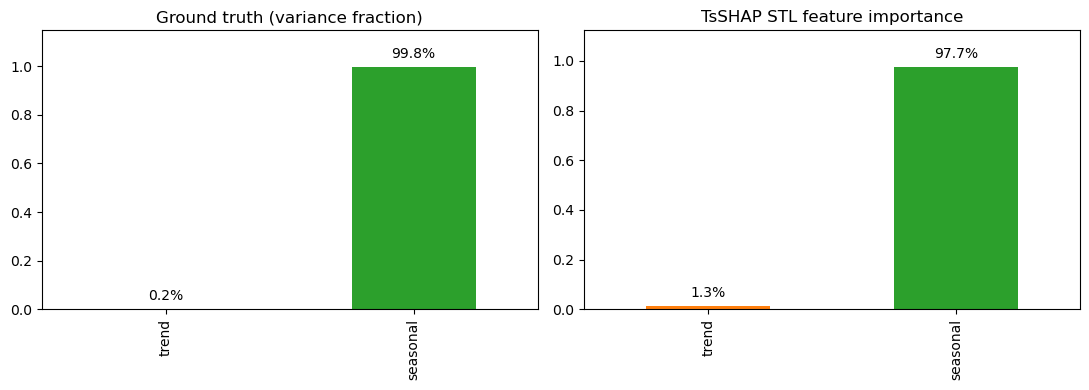

In [11]:
import matplotlib.pyplot as plt

gt_fractions = synth.component_fractions()

# Extract STL importances
stl_imp = result_global.feature_importance[[
    c for c in result_global.feature_names if c.startswith('stl_')
]].abs()

stl_normed = stl_imp / stl_imp.sum()
gt_normed = {k: v for k, v in gt_fractions.items() if k in ['trend', 'seasonal']}
gt_total = sum(gt_normed.values())
gt_normed = {k: v / gt_total for k, v in gt_normed.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
gt_bars = pd.Series(gt_normed).plot.bar(
    ax=axes[0], color=['C1', 'C2'], title='Ground truth (variance fraction)'
)
stl_bars = stl_normed[['stl_trend', 'stl_seasonal']].rename(
    {'stl_trend': 'trend', 'stl_seasonal': 'seasonal'}
).plot.bar(
    ax=axes[1], color=['C1', 'C2'], title='TsSHAP STL feature importance'
)

for ax in [gt_bars, stl_bars]:
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(
            f'{h:.1%}',
            (p.get_x() + p.get_width() / 2, h),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=10,
        )
    ax.set_ylim(top=max([patch.get_height() for patch in ax.patches]) * 1.15)

plt.tight_layout()
plt.show()

## Experiment 6: Efficiency — surrogate backends and SHAP algorithms

Standalone timing study (fresh feature/target matrices per series length): fit surrogates with each **available backend** (`sklearn` GradientBoosting, XGBoost, LightGBM), then measure wall-clock time for:

- **Training** the surrogate  
- **TreeSHAP** (`shap.TreeExplainer`) on all valid rows  
- **KernelSHAP** (`shap.KernelExplainer`) on a **small** subset of rows only — full-grid KernelSHAP would be prohibitively slow  

Plots compare surrogate **MAE** (vs black-box backtest targets) against seconds. We do **not** sweep backtesting step size here.

In [11]:
import time
import shap as shap_lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from evaluation.synthetic_data import make_trend_seasonal
from tsshap.features import LagFeatures, SeasonalLagFeatures, TrendFeatures, RollingWindowFeatures
from tsshap.forecasters import SeasonalNaiveForecaster
from tsshap.backtesting import expanding_window_backtest
from tsshap.surrogate import SurrogateModel

# ── Configuration ─────────────────────────────────────────────────────────────
SERIES_LENGTHS = [120, 240, 480]
BACKENDS = ["sklearn"]          # extend to ["sklearn", "xgboost", "lightgbm"] if those are installed

# Detect which backends are actually available on this machine
for candidate in ["xgboost", "lightgbm"]:
    try:
        SurrogateModel(backend=candidate)._build_model()
        if candidate not in BACKENDS:
            BACKENDS.append(candidate)
    except Exception:
        pass

print(f"Available backends: {BACKENDS}")
print(f"Series lengths to test: {SERIES_LENGTHS}")

Available backends: ['sklearn', 'xgboost', 'lightgbm']
Series lengths to test: [120, 240, 480]


In [12]:
def build_feature_matrix(y, horizon=12):
    """Build the feature matrix and backtested targets for a given series."""
    extractors = [
        LagFeatures(lags=6),
        SeasonalLagFeatures(lags=1, period=12),
        TrendFeatures(degree=1),
        RollingWindowFeatures(window=6, stats=('mean', 'std')),
    ]
    frames = []
    for ext in extractors:
        ext.fit(y)
        frames.append(ext.transform(y))
    X = pd.concat(frames, axis=1)

    bt = expanding_window_backtest(
        y=y,
        forecaster=SeasonalNaiveForecaster(period=12),
        horizon=horizon,
        refit=True,
    )
    return X, bt.forecasts


def time_backend(backend: str, X: pd.DataFrame, y_bt: pd.Series, n_kernel_bg: int = 50):
    """
    Fit the surrogate with `backend`, time training and both SHAP methods.

    Returns dict with: train_time, treeshap_time, kernelshap_time, mae, rmse, r2
    """
    X_clean = X.fillna(0)
    valid = ~y_bt.isna()
    X_v = X_clean.loc[valid]
    y_v = y_bt.loc[valid]

    # ── 1. Training time ──────────────────────────────────────────────────────
    model = SurrogateModel(backend=backend)
    t0 = time.perf_counter()
    model.fit(X_v, y_v)
    train_time = time.perf_counter() - t0

    # ── 2. TreeSHAP time ──────────────────────────────────────────────────────
    t0 = time.perf_counter()
    shap_vals_tree = model.shap_values(X_v)
    treeshap_time = time.perf_counter() - t0

    # ── 3. KernelSHAP time (on a subsample — KernelSHAP is O(2^d) so keep small) ──
    # KernelExplainer passes raw numpy arrays to the predict fn, so we wrap
    # model.predict to reconstruct a DataFrame with the correct column names.
    cols = list(X_v.columns)
    def predict_fn(arr):
        return model.predict(pd.DataFrame(arr, columns=cols))

    bg_size = min(n_kernel_bg, len(X_v))
    bg = X_v.values[:bg_size]
    kernel_explainer = shap_lib.KernelExplainer(predict_fn, bg)
    sample_size = min(30, len(X_v))       # only time on 30 rows so it's feasible
    t0 = time.perf_counter()
    kernel_explainer.shap_values(X_v.values[:sample_size], nsamples=100, silent=True)
    kernelshap_time = time.perf_counter() - t0

    # ── 4. Accuracy metrics ───────────────────────────────────────────────────
    preds = model.predict(X_v)
    residuals = y_v.values - preds
    mae  = float(np.mean(np.abs(residuals)))
    rmse = float(np.sqrt(np.mean(residuals ** 2)))
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y_v.values - y_v.values.mean()) ** 2)
    r2   = float(1 - ss_res / (ss_tot + 1e-10))

    return {
        "train_time":       train_time,
        "treeshap_time":    treeshap_time,
        "kernelshap_time":  kernelshap_time,
        "mae":  mae,
        "rmse": rmse,
        "r2":   r2,
    }


print("Helper functions defined — ready to run experiments.")

Helper functions defined — ready to run experiments.


In [13]:
records = []

for n in SERIES_LENGTHS:
    print(f"\n── Series length n={n} ──────────────────────────────")
    synth_eff = make_trend_seasonal(
        n=n, period=12,
        trend_slope=0.4, seasonal_amplitude=2.0, noise_std=0.3,
        freq='ME', seed=0,
    )
    X, y_bt = build_feature_matrix(synth_eff.series, horizon=12)

    for backend in BACKENDS:
        print(f"  backend={backend} ...", end=" ", flush=True)
        try:
            res = time_backend(backend, X, y_bt)
            res.update({"n": n, "backend": backend})
            records.append(res)
            print(f"train={res['train_time']:.2f}s  "
                  f"TreeSHAP={res['treeshap_time']:.2f}s  "
                  f"KernelSHAP={res['kernelshap_time']:.2f}s  "
                  f"MAE={res['mae']:.4f}  R²={res['r2']:.4f}")
        except Exception as e:
            print(f"SKIPPED ({e})")

results_df = pd.DataFrame(records)
print("\nResults summary:")
print(results_df.to_string(index=False))


── Series length n=120 ──────────────────────────────
  backend=sklearn ... train=0.07s  TreeSHAP=0.01s  KernelSHAP=0.24s  MAE=0.0001  R²=1.0000
  backend=xgboost ... train=0.13s  TreeSHAP=0.00s  KernelSHAP=0.08s  MAE=0.0006  R²=1.0000
  backend=lightgbm ... train=0.07s  TreeSHAP=0.00s  KernelSHAP=0.13s  MAE=0.0732  R²=0.9949

── Series length n=240 ──────────────────────────────
  backend=sklearn ... train=0.08s  TreeSHAP=0.02s  KernelSHAP=0.23s  MAE=0.0004  R²=1.0000
  backend=xgboost ... train=0.13s  TreeSHAP=0.00s  KernelSHAP=0.09s  MAE=0.0019  R²=1.0000
  backend=lightgbm ... train=0.10s  TreeSHAP=0.00s  KernelSHAP=0.21s  MAE=0.0279  R²=0.9985

── Series length n=480 ──────────────────────────────
  backend=sklearn ... train=0.14s  TreeSHAP=0.04s  KernelSHAP=0.19s  MAE=0.0009  R²=1.0000
  backend=xgboost ... train=0.14s  TreeSHAP=0.01s  KernelSHAP=0.08s  MAE=0.0030  R²=1.0000
  backend=lightgbm ... train=0.13s  TreeSHAP=0.01s  KernelSHAP=0.24s  MAE=0.0147  R²=0.9996

Results summ

### Experiment 6 (continued): Tradeoff plots

Three panels:
1. **MAE vs training time** — surrogate error to the black-box backtest target vs seconds to fit  
2. **MAE vs TreeSHAP time** — same vs seconds for TreeSHAP on all valid rows  
3. **TreeSHAP vs KernelSHAP cost** — grouped bars (green = TreeSHAP on *all* valid rows, orange = KernelSHAP on ~30 samples) with **log-scaled time** so sub-second TreeSHAP isn’t flattened; each group is annotated **×N** = “KernelSHAP took *N×* longer than TreeSHAP” under this protocol.

Point size encodes series length $n$. On panels 1–2, **lower-left** is better.

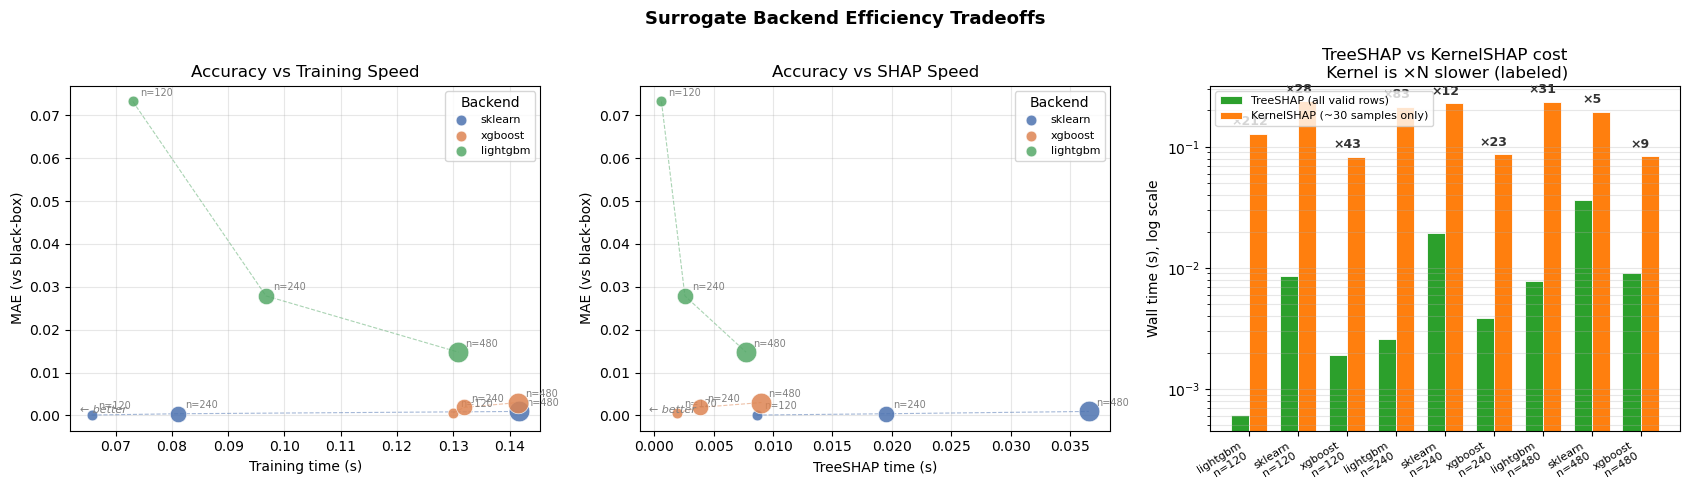

In [14]:
if results_df.empty:
    print("No results to plot — check that at least one backend ran successfully.")
else:
    COLORS = {"sklearn": "#4C72B0", "xgboost": "#DD8452", "lightgbm": "#55A868", "catboost": "#C44E52"}
    SIZE_MAP = {n: 60 + 80 * i for i, n in enumerate(sorted(results_df["n"].unique()))}

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Surrogate Backend Efficiency Tradeoffs", fontsize=13, fontweight="bold")

    scatter_panels = [
        ("train_time",      "mae",  "Training time (s)",    "MAE (vs black-box)",        "Accuracy vs Training Speed"),
        ("treeshap_time",   "mae",  "TreeSHAP time (s)",    "MAE (vs black-box)",        "Accuracy vs SHAP Speed"),
    ]

    for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes[:2], scatter_panels):
        seen_backends = set()
        for _, row in results_df.iterrows():
            backend = row["backend"]
            color = COLORS.get(backend, "gray")
            size = SIZE_MAP.get(row["n"], 100)
            label = backend if backend not in seen_backends else "_nolegend_"
            seen_backends.add(backend)

            ax.scatter(row[xcol], row[ycol],
                       color=color, s=size, alpha=0.85,
                       edgecolors="white", linewidths=0.5,
                       label=label, zorder=3)

            ax.annotate(f"n={int(row['n'])}", (row[xcol], row[ycol]),
                        textcoords="offset points", xytext=(5, 4),
                        fontsize=7, color="gray")

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(title="Backend", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.annotate("← better", xy=(0.02, 0.05), xycoords="axes fraction",
                    fontsize=8, color="gray", style="italic")

    for ax, (xcol, ycol, *_) in zip(axes[:2], scatter_panels):
        for backend in results_df["backend"].unique():
            sub = results_df[results_df["backend"] == backend].sort_values("n")
            ax.plot(sub[xcol], sub[ycol],
                    color=COLORS.get(backend, "gray"),
                    linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)

    # Panel 3: grouped bars + log scale + explicit speedup (clearer than seconds-vs-seconds scatter)
    ax = axes[2]
    df3 = results_df.sort_values(["n", "backend"]).reset_index(drop=True)
    xpos = np.arange(len(df3))
    bar_w = 0.37
    tree_h = np.maximum(df3["treeshap_time"].astype(float).values, 1e-10)
    ker_h = df3["kernelshap_time"].astype(float).values

    ax.bar(xpos - bar_w / 2, tree_h, bar_w,
           label="TreeSHAP (all valid rows)", color="#2ca02c", edgecolor="white", linewidth=0.6)
    ax.bar(xpos + bar_w / 2, ker_h, bar_w,
           label="KernelSHAP (~30 samples only)", color="#ff7f0e", edgecolor="white", linewidth=0.6)

    ax.set_xticks(xpos)
    ax.set_xticklabels(
        [f"{r.backend}\nn={int(r.n)}" for _, r in df3.iterrows()], rotation=32, ha="right", fontsize=8
    )
    ax.set_ylabel("Wall time (s), log scale")
    ax.set_yscale("log")
    ax.set_title("TreeSHAP vs KernelSHAP cost\n Kernel is ×N slower (labeled)")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3, which="both")

    for i in range(len(df3)):
        t_t = float(df3.loc[i, "treeshap_time"])
        t_k = float(df3.loc[i, "kernelshap_time"])
        ratio = t_k / max(t_t, 1e-15)
        if np.isfinite(ratio):
            top = max(tree_h[i], ker_h[i])
            ax.annotate(
                f"×{ratio:.0f}",
                xy=(xpos[i], top),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                fontsize=9,
                fontweight="bold",
                color="#333333",
            )

    plt.tight_layout()
    plt.show()


In [15]:
# ── Summary table: speedup of TreeSHAP over KernelSHAP ─────────────────────
if not results_df.empty:
    summary = results_df.copy()
    summary["treeshap_vs_kernelshap_speedup"] = (
        summary["kernelshap_time"] / summary["treeshap_time"].replace(0, float("nan"))
    ).round(1)
    summary["kernelshap_per_sample_ms"] = (
        summary["kernelshap_time"] / 30 * 1000   # 30 = sample_size used above
    ).round(2)
    summary["treeshap_per_sample_ms"] = (
        summary["treeshap_time"] / summary["n"] * 1000
    ).round(3)

    cols = ["backend", "n", "mae", "r2", "train_time",
            "treeshap_time", "kernelshap_time", "treeshap_vs_kernelshap_speedup"]
    print(summary[cols].sort_values(["n", "backend"]).to_string(index=False))
    print("\nNote: KernelSHAP time is measured on 30 samples only (full dataset would be much longer).")

 backend   n      mae       r2  train_time  treeshap_time  kernelshap_time  treeshap_vs_kernelshap_speedup
lightgbm 120 0.073231 0.994896    0.073054       0.000609         0.128956                           211.6
 sklearn 120 0.000084 1.000000    0.065739       0.008631         0.237602                            27.5
 xgboost 120 0.000599 1.000000    0.129982       0.001911         0.083081                            43.5
lightgbm 240 0.027871 0.998514    0.096708       0.002582         0.214981                            83.2
 sklearn 240 0.000387 1.000000    0.081122       0.019522         0.229283                            11.7
 xgboost 240 0.001866 0.999997    0.131930       0.003831         0.087070                            22.7
lightgbm 480 0.014743 0.999642    0.130919       0.007736         0.236741                            30.6
 sklearn 480 0.000925 0.999999    0.141674       0.036577         0.194924                             5.3
 xgboost 480 0.003002 0.999993    0.1